<a href="https://colab.research.google.com/github/MdShajalalsojib/Machine-Learning-Lab/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [4]:
X_train.shape[0]+X_test.shape[0]

60000

In [5]:
import matplotlib.pyplot as plt

In [6]:
categories = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Text(0.5, 1.0, 'frog')

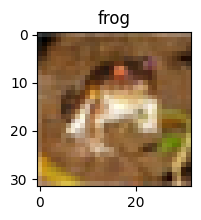

In [7]:
plt.figure(figsize=(2,2))
plt.imshow(X_train[0])
plt.title(categories[y_train.reshape(-1)[0]])

In [8]:
# normalization

X_train = X_train/255
X_test = X_test/255

In [9]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [10]:
X_train[0].shape

(32, 32, 3)

In [13]:
# neural network

ann = models.Sequential(
    [
        layers.Flatten(input_shape=(32,32,3)), # Corrected input shape for CIFAR-10 images
        layers.Dense(100,activation='relu'), # Increased number of neurons for hidden layers
        layers.Dense(50,activation='relu'),
        layers.Dense(10,activation='softmax') # 10 classes for CIFAR-10, using softmax activation
    ]
)

ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(X_train, y_train, epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3112 - loss: 1.9197
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3862 - loss: 1.7299
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4108 - loss: 1.6528
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4313 - loss: 1.6028
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4425 - loss: 1.5624
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4572 - loss: 1.5316
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4665 - loss: 1.5010
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4722 - loss: 1.4777
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4825 - loss: 1.4552
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4895 - loss: 1.4327
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4964 - loss: 1.4153
Epoch 12/20
1563/1563 ━━━━━━━━

In [14]:
loss, accuracy = ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4854 - loss: 1.4538


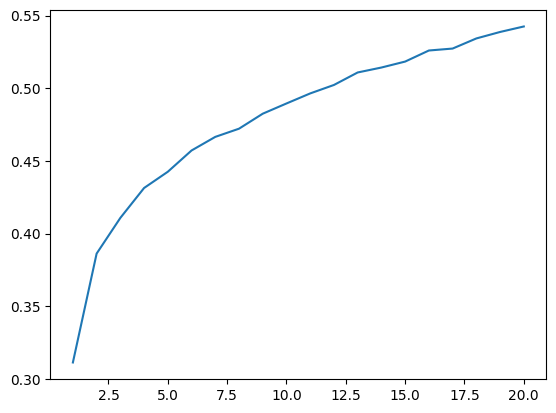

In [15]:
plt.plot(range(1,21),history.history['accuracy'])

In [16]:
y_predict = ann.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [17]:
import numpy as np
np.argmax(y_predict[0]), y_test[0]

(np.int64(3), array([3], dtype=uint8))

In [18]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [19]:
y_predict = [np.argmax(i) for i in y_predict]

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_predict,y_test))

              precision    recall  f1-score   support

           0       0.60      0.53      0.56      1126
           1       0.45      0.74      0.56       606
           2       0.39      0.34      0.36      1135
           3       0.18      0.37      0.24       486
           4       0.44      0.41      0.43      1071
           5       0.53      0.36      0.43      1462
           6       0.54      0.54      0.54       997
           7       0.66      0.48      0.55      1375
           8       0.46      0.74      0.57       626
           9       0.61      0.55      0.58      1116

    accuracy                           0.49     10000
   macro avg       0.49      0.51      0.48     10000
weighted avg       0.51      0.49      0.49     10000

